## Run L96 online with Bayesian NN ensembles

In this notebook we run the coarse one-layer Lorenz 1996 model online with a heteroscedastic Bayesian neural network parameterisation.

We will produce three separate ensembles (20 members each), corresponding to three ways of sampling uncertainty:

- Epistemic only: sample the network weights from the variational posterior; do not add output noise.
- Aleatoric only: keep weights fixed (posterior mean) and sample independent output noise at each time step using the model’s predicted variance.
- Both: sample weights and sample independent output noise.

We use independent (white) noise at each step (no AR(1) temporal correlation). At the end we plot ensemble trajectories.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import pyro

from L96.L96_model import L96OneLayerParam
from scripts.Parameterisation import Parameterisation_VI_Heteroscedastic

from plotting_scripts.plot_ensemble_trajectories import plot_ensembles


/Users/lauraman/Documents/Oxford/code/L96_UQ/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)


# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping: two layer uses dt=0.001, one layer (coarse) uses dt_f=0.005
dt = 0.001
dt_f = 0.005
T = 4



In [3]:
# Data path should already exist as we have already run the notebook to generate training data
data_path = f'./outputs/'
# Load initial conditions and the truth simulation we ran in notebook 3
X0 = np.load(f'{data_path}/X_init.npy') 
X_true = np.load(f'{data_path}/X_test_dtf.npy')

In [4]:
# Load trained pyro model + guide and the associated variational parameters
output_dicts = torch.load(f"{data_path}/model_best.pt", weights_only=False)
pyro.get_param_store().load(f"{data_path}/pyro_best_params.pt")

pyro_model = output_dicts["model"]
guide = output_dicts["guide"]

print(pyro_model)
print(guide)


BayesianNN_Heteroscedastic(
  (layers): PyroModuleList(
    (0): PyroLinear(in_features=1, out_features=16, bias=True)
    (1): PyroLinear(in_features=16, out_features=16, bias=True)
    (2): PyroLinear(in_features=16, out_features=2, bias=True)
  )
  (activation_function): ReLU()
)
AutoMultivariateNormal()


### Define the stochastic parameterisations

We use the same parameterisation wrapper defined in `scripts/Parameterisation.py` to define the parameterisation functions. Each of these will be called in the one-layer L96 integrator at each timestep, and must take as input `x` the current state vector of length `K`, and return `u`, the subgrid tendency, a vector with the same shape.


In [ ]:
# Helper functions within class Parameterisation that turn BNN into 
# a parameterisation that samples epistemic/aleatoric/both
from scripts.Parameterisation import Parameterisation_VI_Heteroscedastic

parameterisation = Parameterisation_VI_Heteroscedastic(pyro_model, guide=guide)

epistemic_param_func = parameterisation.WN_param_epistemic
aleatoric_param_func = parameterisation.WN_param_aleatoric
both_param_func = parameterisation.WN_param_both

### Run ensembles online

Here we run the one-layer L96 model online with each stochastic parameterisation.

For each run type (epistemic, aleatoric, both) we:

- run 50 ensemble members,
- start each ensemble member from the same set of initial conditions,
- integrate forward with `L96OneLayerParam(...).iterate(T)`, and
- store the resulting trajectories in arrays of shape `(n_ens, n_time_total, K)`.

Here, we use white noise at each step, so we take one sample from the BNN without any temporal correlations imposed.

In [11]:
N_ens = 50
# Epistemic
def param_func(x):
    param_sample = guide()
    # Use selected parameters to set up NN
    nn = pyro_model.get_fixed_param_NN(param_sample)
    with torch.no_grad():
        out = nn(x.unsqueeze(-1))
    # For epistemic, only return the first output
    mu, _  = out.chunk(2, dim=-1)
    return mu.squeeze()

X_epi = np.zeros((N_ens, int(T/dt_f), K))
# Loop over ensembles
for n in range(N_ens): 
    l96_model = L96OneLayerParam(X_0=torch.tensor(X0, dtype=torch.float32), 
                                param_func=epistemic_param_func, 
                                dt=dt_f, 
                                F=F)
    # Run model
    X, U, time = l96_model.iterate(T)
    X_epi[n] = X


In [12]:
# Aleatoric
def param_func(x):
    # Use mean parameters
    nn = pyro_model.get_fixed_param_NN(guide.median())
    with torch.no_grad():
        out = nn(x.unsqueeze(-1))
    # For aleatoric, sample from the data uncertainty
    mu, sigma  = out.chunk(2, dim=-1)
    sigma = torch.exp(sigma) + pyro_model.eps
    if any([(torch.abs(sig) > 100.) for sig in sigma]):
        return param_func(x)
    return mu.squeeze() + sigma.squeeze() * np.random.randn(x.shape[0])


X_ale = np.zeros((N_ens, int(T/dt_f), K))
# Loop over ensembles
for n in range(N_ens): 
    l96_model = L96OneLayerParam(X_0=torch.tensor(X0, dtype=torch.float32), 
                                param_func=aleatoric_param_func, 
                                dt=dt_f, 
                                F=F)
    # Run model
    X, U, time = l96_model.iterate(T)
    X_ale[n] = X


In [13]:
# Both
def param_func(x):
    # For epistemic, sample params from variational distribution
    param_sample = guide()
    nn = pyro_model.get_fixed_param_NN(param_sample)
    with torch.no_grad():
        out = nn(x.unsqueeze(-1))
    # For aleatoric, sample from the data uncertainty
    mu, sigma  = out.chunk(2, dim=-1)
    sigma = torch.exp(sigma) + pyro_model.eps
    if any([(torch.abs(sig) > 100.) for sig in sigma]):
        return param_func(x)
    return mu.squeeze() + sigma.squeeze() * np.random.randn(x.shape[0])


X_both = np.zeros((N_ens, int(T/dt_f), K))
# Loop over ensembles
for n in range(N_ens): 
    l96_model = L96OneLayerParam(X_0=torch.tensor(X0, dtype=torch.float32), 
                                param_func=both_param_func, 
                                dt=dt_f, 
                                F=F)
    # Run model
    X, U, time = l96_model.iterate(T)
    X_both[n]=X


In [14]:
X_both.shape, X_epi.shape, X_ale.shape

((50, 800, 8), (50, 800, 8), (50, 800, 8))

### Plot ensembles

We will plot the trajectories of each ensemble for the three parameterisations: epistemic, aleatoric, and both and compare these against the truth.

<Figure size 640x480 with 0 Axes>

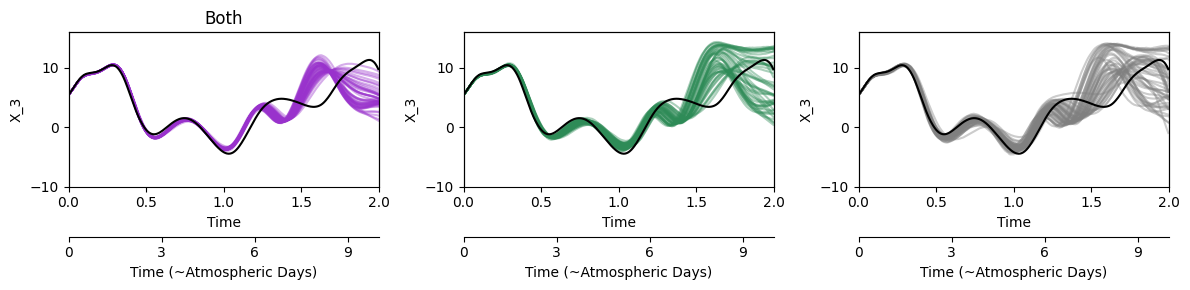

In [15]:
from utils.add_time_axis import add_axis_weather

k = 3
max_steps = 400
plt.clf()
fig, axs = plt.subplots(1, 3, figsize=(12, 3)) 
# Epistemic
for n in range(N_ens):
    axs[0].plot(time[0:max_steps], X_epi[n, 0:max_steps, k],
    alpha=0.4, color="darkorchid")
axs[0].set_title("Epistemic")

# Aleatoric
for n in range(N_ens):
    axs[1].plot(time[0:max_steps], X_ale[n, 0:max_steps, k],
    alpha=0.4, color="seagreen")
axs[0].set_title("Aleatoric")

# Both
for n in range(N_ens):
    axs[2].plot(time[0:max_steps], X_both[n, 0:max_steps, k],
    alpha=0.4, color="gray")
axs[0].set_title("Both")


# Add truth to all three plots and axis
for j in range(3):
    axs[j].plot(time[0:max_steps], X_true[:max_steps, k],
            label="Truth", alpha=1., color="black")
        
    axs[j].axis(xmin=0, xmax=int(max_steps*dt_f), ymin = -10., ymax=16.)
    axs[j].set_ylabel(f"X_{k}")
    axs[j].set_xlabel("Time")
    add_axis_weather(axs[j], 25, 3)
plt.tight_layout()


## Summary
Here we can see that ensemble members begin to diverge after around 3 atmospheric days, and that epistemic uncertainty is smaller compared to aleatoric uncertainty with the simulaions diverging at a slower rate. In other words, **uncertainty arising from the subgrid variability in the data dominates on short timescales**. Here, we used a simple parameterisation with no temporal memory, but in the full codebase you can explore how the effect of including an AR1 process that accounts for correlations in time will further improve the forecast spread. We have also explored extending this to climate-style simulations, where we see the influence of epistemic uncertainty becomes more relevant. 